In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# Single gene-trait association plots

In [7]:
## Single gene-trait association plot
gene_name = 'LDLR'
phenotype = 'mean_corpuscular_volume_int'

In [8]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""conservation""","""gpn_score""","""#942c80""","""GPN-MSA""",-1
"""conservation""","""zooverphylop""","""#6a1c81""","""Zoonomia vertebrate PhyloP""",1
…,…,…,…,…
"""regulatory""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1
"""regulatory""","""promoterai_under""","""#00A99D""","""PromoterAI under""",-1
"""regulatory""","""promoterai_over""","""#00A99D""","""PromoterAI over""",1


In [11]:
anno = pl.scan_parquet(f"/home/dnanexus/data_dir/genebass1e6_genes_10kb_allvars_annotated_250925.parquet").filter(pl.col('gene_name') == gene_name).collect(engine='streaming')

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
)

phenotype = anno['region'].unique()[0] + '_olink'
anno

esmscoremissense,abexp_min,gene_length,delta_score,absplice_dna_max,TSS,zooverphylop,promoterai_over,relative_cds_position,region,gene_name,gpn_score,Strand,pangolin_score,dist_to_tss,promoterai_under,promoterai_abs,cadd_raw,am_pathogenicity,verphylop,abexp_max,id,promoterai,absplice2_max
f32,f64,i64,f32,f32,i64,f32,f32,f32,str,str,f32,cat,f32,i64,f32,f32,f32,f32,f32,f64,str,f32,f32
0.0,-0.005877,44360,0.0,0.001,11089461,-0.12,0.0,0.0,"""ENSG00000130164""","""LDLR""",0.05,"""+""",0.0,4277,0.0,0.0,0.372048,0.0,-0.141,-0.005501,"""chr19:11093738:G:A""",0.0,0.000033
0.0,-0.005877,44360,0.0,0.001,11089461,-2.853,0.0,0.0,"""ENSG00000130164""","""LDLR""",-0.87,"""+""",0.0,21488,0.0,0.0,-0.889739,0.0,-1.677,-0.005501,"""chr19:11110949:G:A""",0.0,0.000033
0.0,0.002093,44360,0.0,0.0,11089461,-1.109,0.0,0.0,"""ENSG00000130164""","""LDLR""",0.18,"""+""",0.0,48226,0.0,0.0,-0.0706,0.0,-1.413,0.002469,"""chr19:11137687:A:C""",0.0,0.0
0.0,-0.005605,44360,0.0,0.001,11089461,-1.837,0.0,0.0,"""ENSG00000130164""","""LDLR""",-1.16,"""+""",0.0,42447,0.0,0.0,-0.358473,0.0,-2.955,-0.005229,"""chr19:11131908:T:C""",0.0,0.000033
0.0,-0.005877,44360,0.0,0.001,11089461,-0.848,0.0,0.0,"""ENSG00000130164""","""LDLR""",-1.39,"""+""",0.0,10209,0.0,0.0,-0.016461,0.0,0.365,-0.005501,"""chr19:11099670:C:G""",0.0,0.000033
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,null,44360,0.0,0.0,11089461,-0.146,0.0,0.0,"""ENSG00000130164""","""LDLR""",-1.46,"""+""",0.0,31791,0.0,0.0,0.0,0.0,0.042,null,"""chr19:11121252:TGAGGATTG:T""",0.0,0.0
0.0,null,44360,0.0,0.0,11089461,-0.146,0.0,0.0,"""ENSG00000130164""","""LDLR""",-1.46,"""+""",0.0,-4494,0.0,0.0,0.0,0.0,0.042,null,"""chr19:11084967:C:CAAAAAACA""",0.0,0.0
0.0,null,44360,0.0,0.0,11089461,-0.146,0.0,0.0,"""ENSG00000130164""","""LDLR""",-1.46,"""+""",0.0,7596,0.0,0.0,0.0,0.0,0.042,null,"""chr19:11097057:ATT:A""",0.0,0.0


In [12]:
melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr19:11093738:G:A""","""ENSG00000130164""","""cadd_raw""",0.372048
"""chr19:11110949:G:A""","""ENSG00000130164""","""cadd_raw""",-0.889739
"""chr19:11137687:A:C""","""ENSG00000130164""","""cadd_raw""",-0.0706
"""chr19:11131908:T:C""","""ENSG00000130164""","""cadd_raw""",-0.358473
"""chr19:11099670:C:G""","""ENSG00000130164""","""cadd_raw""",-0.016461
…,…,…,…
"""chr19:11121252:TGAGGATTG:T""","""ENSG00000130164""","""abexp_max""",null
"""chr19:11084967:C:CAAAAAACA""","""ENSG00000130164""","""abexp_max""",null
"""chr19:11097057:ATT:A""","""ENSG00000130164""","""abexp_max""",null


In [15]:
olink_appv = pl.read_parquet("/home/dnanexus/data_dir/olink_appv_chunks_EUR_coding/variant_pheno_EUR.parquet")

appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac) &
        (pl.col('phenotype') == phenotype)
    )
)

appv

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value
str,str,u64,f32,f32
"""chr1:10132437:C:T""","""ENSG00000130164_olink""",3,-0.053659,1.32232
"""chr1:11134400:C:T""","""ENSG00000130164_olink""",1,0.05923,null
"""chr1:2306706:T:C""","""ENSG00000130164_olink""",2,0.024012,0.336165
"""chr1:3731014:G:A""","""ENSG00000130164_olink""",1,-0.003955,null
"""chr1:9872043:C:T""","""ENSG00000130164_olink""",2,-0.464878,null
…,…,…,…,…
"""chr22:50278862:C:T""","""ENSG00000130164_olink""",1,-1.395957,null
"""chr22:50287251:A:G""","""ENSG00000130164_olink""",1,2.229291,null
"""chr22:50459662:G:A""","""ENSG00000130164_olink""",1,-0.561347,null


In [17]:
# Merge phenotype data and annotation data
pg_df = (
    appv
    .join(
        melted_anno, 
        on="id", 
        how="inner"
    )
    .join(
        anno.select(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']), 
        on=['id', 'region'], 
        how='inner'
    )
)

# Join with experimental data
# pg_df = pg_df.join(exp_data.filter(pl.col('gene_name') == gene_name), on='id', how='inner')
pg_df

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss
str,str,u64,f32,f32,str,str,f32,i64,cat,i64,str,i64
"""chr19:11100305:T:C""","""ENSG00000130164_olink""",1,1.444661,null,"""ENSG00000130164""","""cadd_raw""",-0.554099,11089461,"""+""",44360,"""LDLR""",10844
"""chr19:11100305:T:C""","""ENSG00000130164_olink""",1,1.444661,null,"""ENSG00000130164""","""am_pathogenicity""",0.0,11089461,"""+""",44360,"""LDLR""",10844
"""chr19:11100305:T:C""","""ENSG00000130164_olink""",1,1.444661,null,"""ENSG00000130164""","""esmscoremissense""",0.0,11089461,"""+""",44360,"""LDLR""",10844
"""chr19:11100305:T:C""","""ENSG00000130164_olink""",1,1.444661,null,"""ENSG00000130164""","""gpn_score""",0.94,11089461,"""+""",44360,"""LDLR""",10844
"""chr19:11100305:T:C""","""ENSG00000130164_olink""",1,1.444661,null,"""ENSG00000130164""","""zooverphylop""",-8.23,11089461,"""+""",44360,"""LDLR""",10844
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr19:11105470:C:T""","""ENSG00000130164_olink""",2,-0.143704,0.95948,"""ENSG00000130164""","""promoterai_abs""",0.0297,11089461,"""+""",44360,"""LDLR""",16009
"""chr19:11105470:C:T""","""ENSG00000130164_olink""",2,-0.143704,0.95948,"""ENSG00000130164""","""promoterai_under""",-0.0297,11089461,"""+""",44360,"""LDLR""",16009
"""chr19:11105470:C:T""","""ENSG00000130164_olink""",2,-0.143704,0.95948,"""ENSG00000130164""","""promoterai_over""",0.0,11089461,"""+""",44360,"""LDLR""",16009


In [18]:
pg_df['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""cadd_raw""",57
"""am_pathogenicity""",57
"""esmscoremissense""",57
"""gpn_score""",57
"""zooverphylop""",57
…,…
"""promoterai_abs""",57
"""promoterai_under""",57
"""promoterai_over""",57


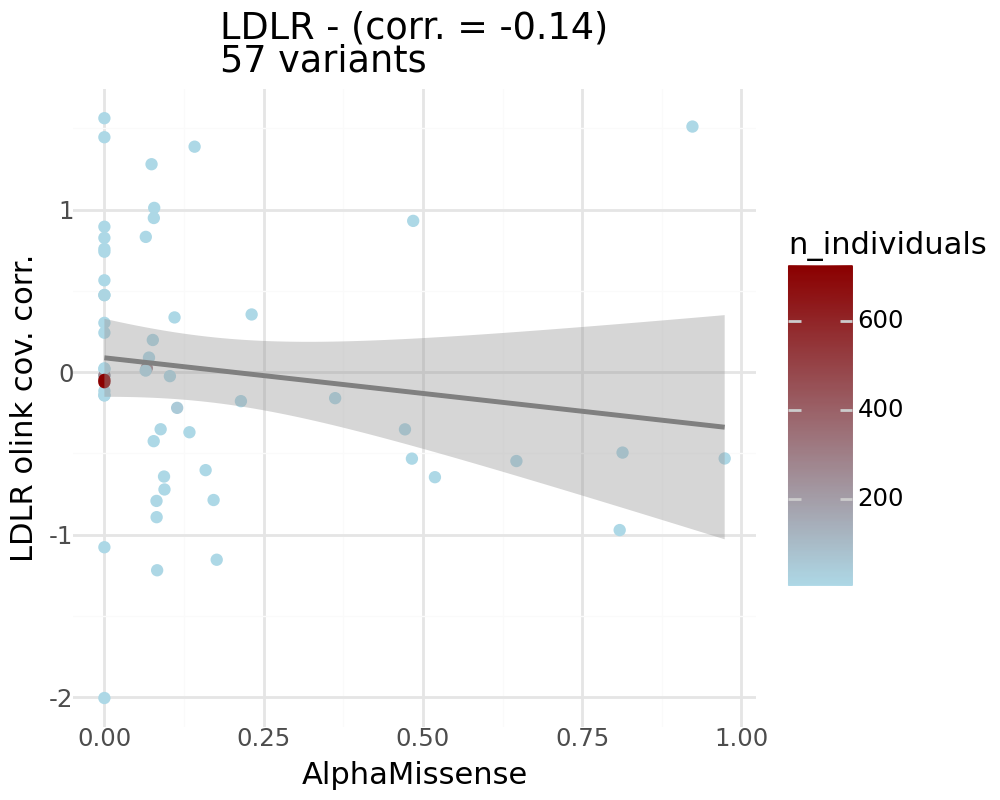

In [28]:
annotation = 'am_pathogenicity'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{gene_name} olink cov. corr.",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)